In [8]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision.models import densenet121
import numpy as np
import torch.nn.functional as F
from torch.utils.data import Dataset
from tqdm import tqdm
from recon_datasetv2 import ReconDataset
from torch.utils.data import DataLoader
import h5py
from torch.utils.data import random_split, DataLoader
from torch.utils.data import ConcatDataset

torch.cuda.is_available()

False

In [3]:
# parameters
EPOCHS = 20
BSize = 8

if BSize==8:
    EPOCHS = 10

model_lr=3e-5

In [4]:
with h5py.File('Data_SheppLogan_Test1/data.mat', 'r') as f:
    print(list(f.keys()))  # see variables inside
    
    # example: load a dataset
    N = f['N'][:]
    img_truth = f['img'][:]
    total_recon_curr = f['total_recon_curr'][:]
    total_recon_next = f['total_recon_next'][:]
    total_lambda = f['total_lambda'][:]

print('verifying shepplogan dataset')
print(total_recon_curr.shape)
print(total_recon_next.shape)
print(total_lambda.shape)

dataset_SheppLogan = ReconDataset(
    total_recon_curr,
    total_recon_next,
    total_lambda
)

# reproducible split
generator = torch.Generator().manual_seed(42)

# lengths
dataset_size = len(dataset_SheppLogan)

train_size = int(0.70 * dataset_size)
val_size   = int(0.15 * dataset_size)
test_size  = dataset_size - train_size - val_size

# split
train_dataset_SL, val_dataset_SL, test_dataset_SL = random_split(
    dataset_SheppLogan,
    [train_size, val_size, test_size],
    generator=generator
)

print(len(train_dataset_SL))
print(len(val_dataset_SL))
print(len(test_dataset_SL))

loader_SheppLogan = DataLoader(
    train_dataset_SL,
    batch_size=BSize,
    shuffle=True
)

loader_val_SL = DataLoader(
    val_dataset_SL,
    batch_size=BSize,
    shuffle=False
)

loader_test_SL = DataLoader(
    test_dataset_SL,
    batch_size=BSize,
    shuffle=False
)

with h5py.File('Data_Cameraman_Test1/data.mat', 'r') as f:
    print(list(f.keys()))  # see variables inside
    
    # example: load a dataset
    N = f['N'][:]
    img_truth = f['img'][:]
    total_recon_curr = f['total_recon_curr'][:]
    total_recon_next = f['total_recon_next'][:]
    total_lambda = f['total_lambda'][:]

print('verifying cameraman dataset')
print(total_recon_curr.shape)
print(total_recon_next.shape)
print(total_lambda.shape)

dataset_Cameraman = ReconDataset(
    total_recon_curr,
    total_recon_next,
    total_lambda
)

# reproducible split
generator = torch.Generator().manual_seed(42)

# lengths
dataset_size = len(dataset_Cameraman)

train_size = int(0.70 * dataset_size)
val_size   = int(0.15 * dataset_size)
test_size  = dataset_size - train_size - val_size

# split
train_dataset_Ca, val_dataset_Ca, test_dataset_Ca = random_split(
    dataset_Cameraman,
    [train_size, val_size, test_size],
    generator=generator
)

print(len(train_dataset_Ca))
print(len(val_dataset_Ca))
print(len(test_dataset_Ca))


loader_Cameraman = DataLoader(
    train_dataset_Ca,
    batch_size=BSize,
    shuffle=True
)

loader_val_Ca = DataLoader(
    val_dataset_Ca,
    batch_size=BSize,
    shuffle=False
)

loader_test_Ca = DataLoader(
    test_dataset_Ca,
    batch_size=BSize,
    shuffle=False
)

with h5py.File('Data_Forblid_Test1/data.mat', 'r') as f:
    print(list(f.keys()))  # see variables inside
    
    # example: load a dataset
    N = f['N'][:]
    img_truth = f['img'][:]
    total_recon_curr = f['total_recon_curr'][:]
    total_recon_next = f['total_recon_next'][:]
    total_lambda = f['total_lambda'][:]

print('verifying cameraman dataset')
print(total_recon_curr.shape)
print(total_recon_next.shape)
print(total_lambda.shape)

dataset_Forblid = ReconDataset(
    total_recon_curr,
    total_recon_next,
    total_lambda
)

# reproducible split
generator = torch.Generator().manual_seed(42)

# lengths
dataset_size = len(dataset_Forblid)

train_size = int(0.70 * dataset_size)
val_size   = int(0.15 * dataset_size)
test_size  = dataset_size - train_size - val_size

# split
train_dataset_Forblid, val_dataset_Forblid, test_dataset_Forblid = random_split(
    dataset_Forblid,
    [train_size, val_size, test_size],
    generator=generator
)

print('verifying forblid dataset')
print(len(train_dataset_Forblid))
print(len(val_dataset_Forblid))
print(len(test_dataset_Forblid))


loader_train_Forblid = DataLoader(
    train_dataset_Forblid,
    batch_size=BSize,
    shuffle=True
)

loader_val_Forblid = DataLoader(
    val_dataset_Forblid,
    batch_size=BSize,
    shuffle=False
)

loader_test_Forblid = DataLoader(
    test_dataset_Forblid,
    batch_size=BSize,
    shuffle=False
)

['N', 'img', 'total_lambda', 'total_recon_curr', 'total_recon_next']
verifying shepplogan dataset
(7213, 64, 64)
(7213, 64, 64)
(7213, 1)
5049
1081
1083
['N', 'img', 'total_lambda', 'total_recon_curr', 'total_recon_next']
verifying cameraman dataset
(6351, 64, 64)
(6351, 64, 64)
(6351, 1)
4445
952
954
['N', 'img', 'total_lambda', 'total_recon_curr', 'total_recon_next']
verifying cameraman dataset
(3720, 64, 64)
(3720, 64, 64)
(3720, 1)
verifying forblid dataset
2604
558
558


In [5]:
class LambdaModel(nn.Module): 
    def __init__(self): 
        super().__init__() 
        base = densenet121(weights="IMAGENET1K_V1") 
        # base = xrv.models.DenseNet(weights="densenet121-res224-all")
        
        # Feature extractor (DenseNet backbone) 
        self.backbone = nn.Sequential( base.features, 
                                       nn.ReLU(inplace=True), 
                                       nn.AdaptiveAvgPool2d((1, 1)) ) 
        
        self.head = nn.Sequential( nn.Flatten(), 
                                   nn.Linear(1024, 128), 
                                   nn.ReLU(inplace=True), 
                                   nn.Linear(128, 64), 
                                   nn.ReLU(inplace=True), 
                                   nn.Linear(64, 1) ) 
    def forward(self, x): 
        # grayscale → 3-channel 
        # if x.shape[1] == 1: 
        #     x = x.repeat(1, 3, 1, 1) 
        x = self.backbone(x) 
        lambda_raw = self.head(x) 
        # bound λ ∈ [0.05, 2] 
        lambda_out = 0.05 + (2.0 - 0.05) * torch.sigmoid(lambda_raw) # this works better for SheppLogan Dataset
        # lambda_out = F.softplus(lambda_raw) + 1e-3
        return lambda_out
        
class LambdaPrediction(nn.Module): 
    def __init__(self): 
        super().__init__() 
        self.lambdaModel = LambdaModel() 
    def forward(self, x_curr, x_next, lam_true): 
        lam_pred = self.lambdaModel(x_curr.repeat(1, 3, 1, 1)) # need this if using imagenet1k_v1
        # lam_pred = self.lambdaModel(x_curr) # this is for res224 (med img version)
        lam_true = lam_true.view(lam_true.size(0), 1, 1, 1) 
        direction = (x_next - x_curr) / (lam_true) 
        norm = torch.norm(direction.flatten(1), dim=1, keepdim=True) + 1e-6 
        direction = direction / norm.view(-1,1,1,1) 
        lam_pred = lam_pred.view(lam_pred.size(0), 1, 1, 1) 
        x_pred = x_curr + lam_pred * direction 
        
        loss = torch.mean((lam_pred - lam_true)**2) 
        
        return loss, lam_pred

In [6]:

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(device)

mps


In [7]:
train_losses = []
val_losses = []

model_shepplogan = LambdaPrediction().to(device)

optimizer = torch.optim.Adam(
    model_shepplogan.parameters(),
    lr=model_lr
)

for epoch in range(EPOCHS):

    ########################################
    # TRAIN
    ########################################
    model_shepplogan.train()

    running_train_loss = 0.0

    pbar = tqdm(loader_SheppLogan, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for x_curr, x_next, lam_true in pbar:

        x_curr = x_curr.to(device)
        x_next = x_next.to(device)
        lam_true = lam_true.to(device)

        # forward
        loss_i, lam_pred = model_shepplogan(
            x_curr,
            x_next,
            lam_true
        )

        # backward
        optimizer.zero_grad()

        loss_i.backward()

        torch.nn.utils.clip_grad_norm_(
            model_shepplogan.parameters(),
            1.0
        )

        optimizer.step()

        running_train_loss += loss_i.item()

        pbar.set_postfix(loss=loss_i.item())

    avg_train_loss = running_train_loss / len(loader_SheppLogan)

    ########################################
    # VALIDATION
    ########################################
    model_shepplogan.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for x_curr, x_next, lam_true in loader_val_SL:

            x_curr = x_curr.to(device)
            x_next = x_next.to(device)
            lam_true = lam_true.to(device)

            loss_i, lam_pred = model_shepplogan(
                x_curr,
                x_next,
                lam_true
            )

            running_val_loss += loss_i.item()

    avg_val_loss = running_val_loss / len(loader_val_SL)

    ########################################
    # STORE HISTORY
    ########################################
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {avg_train_loss:.6f} | "
        f"Val Loss: {avg_val_loss:.6f}"
    )

Epoch 1/10: 100%|███████████████| 632/632 [02:44<00:00,  3.84it/s, loss=0.00528]


Epoch 1/10 | Train Loss: 0.054803 | Val Loss: 0.050888


Epoch 2/10: 100%|████████████████| 632/632 [02:40<00:00,  3.95it/s, loss=0.0274]


Epoch 2/10 | Train Loss: 0.047487 | Val Loss: 0.066050


Epoch 3/10: 100%|█████████████████| 632/632 [02:36<00:00,  4.03it/s, loss=0.023]


...

Epoch 8/10 | Train Loss: 0.040510 | Val Loss: 0.071304


Epoch 9/10: 100%|███████████████| 632/632 [02:42<00:00,  3.88it/s, loss=0.00974]


Epoch 9/10 | Train Loss: 0.039256 | Val Loss: 0.080033


Epoch 10/10: 100%|███████████████| 632/632 [02:38<00:00,  3.98it/s, loss=0.0416]


Epoch 10/10 | Train Loss: 0.038798 | Val Loss: 0.068920


In [9]:
# testing
model_shepplogan.eval()

test_loss = 0.0

with torch.no_grad():
    i = 0
    for x_curr, x_next, lam_true in loader_test_SL:

        x_curr = x_curr.to(device)
        x_next = x_next.to(device)
        lam_true = lam_true.to(device)

        loss_i, lam_pred = model_shepplogan(
            x_curr,
            x_next,
            lam_true
        )
        if i<BSize:
            print(f"Sample {i}:  pred = {lam_pred[i].item():.6f} | true = {lam_true[i].item():.6f}")
            i+=1
            
        test_loss += loss_i.item()

avg_test_loss = test_loss / len(loader_test_SL)

print("Test Loss:", avg_test_loss)

Sample 0:  pred = 1.201613 | true = 1.150000
Sample 1:  pred = 1.185515 | true = 1.550000
Sample 2:  pred = 1.185410 | true = 1.400000
Sample 3:  pred = 1.186489 | true = 1.300000
Sample 4:  pred = 1.182834 | true = 1.350000
Sample 5:  pred = 1.178852 | true = 1.550000
Sample 6:  pred = 1.169525 | true = 0.650000
Sample 7:  pred = 1.186644 | true = 1.350000
Test Loss: 0.07448551526484902


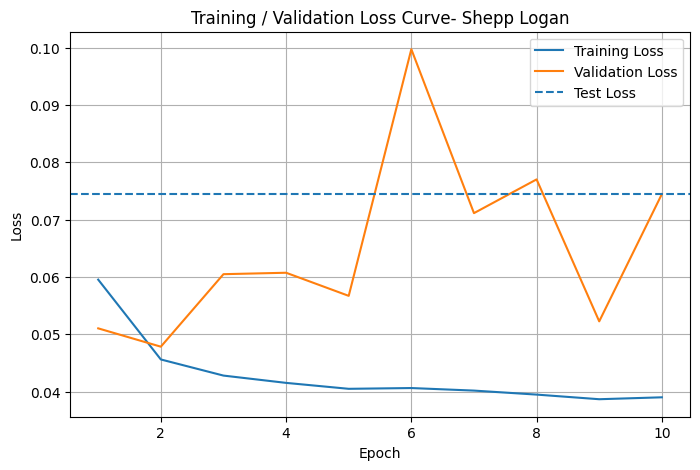

In [11]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))

# Training and validation curves
plt.plot(epochs, train_losses, label='Training Loss')
plt.plot(epochs, val_losses, label='Validation Loss')

# Optional: show test loss as a horizontal line
plt.axhline(y=avg_test_loss, linestyle='--', label='Test Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training / Validation Loss Curve- Shepp Logan')
plt.legend()
plt.grid(True)

plt.show()

In [14]:
# testing model output
# v1 testing
model_shepplogan.eval()
print("\nSL model eval:Sample-wise λ comparison:\n")
for bcount in range(1):
    x_curr, x_next, lam_true = next(iter(loader_SheppLogan))
    
    x_curr = x_curr.to(device)
    x_next = x_next.to(device)
    lam_true = lam_true.to(device)
    with torch.no_grad():
        _, lam_pred = model_shepplogan(x_curr, x_next, lam_true)
    
    for i in range(BSize):
        print(f"Sample {i+bcount*BSize}:  pred = {lam_pred[i].item():.6f} | true = {lam_true[i].item():.6f}")

B, C, H, W = 16, 1, 64, 64  # 10 samples

x_zeros = torch.zeros((BSize, C, H, W)).to(device)
x_curr = x_zeros
x_next = x_zeros  # or you can also test random pairing

with torch.no_grad():
    _, lam_pred = model_shepplogan(x_curr, x_next, lam_true)

print("\nAll-zeros input λ predictions:\n")
for i in range(1):
    print(f"Sample {i}: {lam_pred[i].item():.6f}")

x_ones = torch.ones((BSize, C, H, W)).to(device)
x_curr = x_ones
x_next = x_ones

with torch.no_grad():
    _, lam_pred = model_shepplogan(x_curr, x_next, lam_true)

print("\nAll-ones input λ predictions:\n")
for i in range(1):
    print(f"Sample {i}: {lam_pred[i].item():.6f}")



SL model eval:Sample-wise λ comparison:

Sample 0:  pred = 1.223852 | true = 1.250000
Sample 1:  pred = 1.225160 | true = 0.950000
Sample 2:  pred = 1.212657 | true = 1.700000
Sample 3:  pred = 1.220153 | true = 1.300000
Sample 4:  pred = 1.203756 | true = 1.650000
Sample 5:  pred = 1.224648 | true = 1.250000
Sample 6:  pred = 1.224213 | true = 1.400000
Sample 7:  pred = 1.220159 | true = 1.400000

All-zeros input λ predictions:

Sample 0: 1.518304

All-ones input λ predictions:

Sample 0: 1.463642


In [15]:
model_shepplogan_cpu = model_shepplogan.to("cpu")
model_shepplogan_cpu.eval()
scripted_model_shepplogan = torch.jit.script(model_shepplogan_cpu)
scripted_model_shepplogan.save("TrainedModels/lambda_shepp_test1.pt")

In [12]:
train_losses = []
val_losses = []

model_cameraman = LambdaPrediction().to(device)

optimizer = torch.optim.Adam(
    model_cameraman.parameters(),
    lr=model_lr
)

for epoch in range(EPOCHS):

    ########################################
    # TRAIN
    ########################################
    model_cameraman.train()

    running_train_loss = 0.0

    pbar = tqdm(loader_Cameraman, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for x_curr, x_next, lam_true in pbar:

        x_curr = x_curr.to(device)
        x_next = x_next.to(device)
        lam_true = lam_true.to(device)

        # forward
        loss_i, lam_pred = model_cameraman(
            x_curr,
            x_next,
            lam_true
        )

        # backward
        optimizer.zero_grad()

        loss_i.backward()

        torch.nn.utils.clip_grad_norm_(
            model_cameraman.parameters(),
            1.0
        )

        optimizer.step()

        running_train_loss += loss_i.item()

        pbar.set_postfix(loss=loss_i.item())

    avg_train_loss = running_train_loss / len(loader_Cameraman)

    ########################################
    # VALIDATION
    ########################################
    model_cameraman.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for x_curr, x_next, lam_true in loader_val_Ca:

            x_curr = x_curr.to(device)
            x_next = x_next.to(device)
            lam_true = lam_true.to(device)

            loss_i, lam_pred = model_cameraman(
                x_curr,
                x_next,
                lam_true
            )

            running_val_loss += loss_i.item()

    avg_val_loss = running_val_loss / len(loader_val_Ca)

    ########################################
    # STORE HISTORY
    ########################################
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {avg_train_loss:.6f} | "
        f"Val Loss: {avg_val_loss:.6f}"
    )

Epoch 1/10: 100%|███████████████████████████████████████████████████████| 392/392 [00:26<00:00, 14.68it/s, loss=0.0235]


Epoch 1/10 | Train Loss: 0.059834 | Val Loss: 0.119366


Epoch 2/10: 100%|███████████████████████████████████████████████████████| 392/392 [00:26<00:00, 14.66it/s, loss=0.0297]


Epoch 2/10 | Train Loss: 0.045910 | Val Loss: 0.067786


Epoch 3/10: 100%|███████████████████████████████████████████████████████| 392/392 [00:26<00:00, 14.72it/s, loss=0.0153]


...

Epoch 8/10 | Train Loss: 0.035185 | Val Loss: 0.039732


Epoch 9/10: 100%|███████████████████████████████████████████████████████| 392/392 [00:26<00:00, 14.65it/s, loss=0.0437]


Epoch 9/10 | Train Loss: 0.035654 | Val Loss: 0.100278


Epoch 10/10: 100%|██████████████████████████████████████████████████████| 392/392 [00:26<00:00, 14.68it/s, loss=0.0391]


Epoch 10/10 | Train Loss: 0.034584 | Val Loss: 0.088391


In [13]:
# testing
model_cameraman.eval()

test_loss = 0.0

with torch.no_grad():
    i = 0
    for x_curr, x_next, lam_true in loader_test_Ca:

        x_curr = x_curr.to(device)
        x_next = x_next.to(device)
        lam_true = lam_true.to(device)

        loss_i, lam_pred = model_cameraman(
            x_curr,
            x_next,
            lam_true
        )
        if i<BSize:
            print(f"Sample {i}:  pred = {lam_pred[i].item():.6f} | true = {lam_true[i].item():.6f}")
            i+=1
            
        test_loss += loss_i.item()

avg_test_loss = test_loss / len(loader_test_Ca)

print("Test Loss:", avg_test_loss)

Sample 0:  pred = 1.134077 | true = 1.550000
Sample 1:  pred = 1.196813 | true = 1.000000
Sample 2:  pred = 1.174647 | true = 1.550000
Sample 3:  pred = 1.672755 | true = 1.700000
Sample 4:  pred = 1.160046 | true = 1.300000
Sample 5:  pred = 1.150068 | true = 1.400000
Sample 6:  pred = 1.143624 | true = 0.850000
Sample 7:  pred = 1.201731 | true = 0.600000
Test Loss: 0.09537262306274737


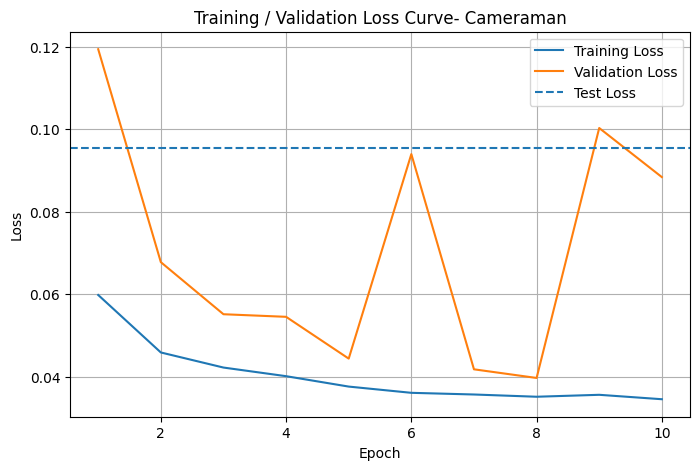

In [15]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))

# Training and validation curves
plt.plot(epochs, train_losses, label='Training Loss')
plt.plot(epochs, val_losses, label='Validation Loss')

# Optional: show test loss as a horizontal line
plt.axhline(y=avg_test_loss, linestyle='--', label='Test Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training / Validation Loss Curve- Cameraman')
plt.legend()
plt.grid(True)

plt.show()

In [14]:
# testing model output
# v1 testing
model_cameraman.eval()
print("\ncameraman model evaluation:Sample-wise λ comparison:\n")
for b in range(1):
    x_curr, x_next, lam_true = next(iter(loader_test_Ca))
    
    x_curr = x_curr.to(device)
    x_next = x_next.to(device)
    lam_true = lam_true.to(device)
    
    with torch.no_grad():
        _, lam_pred = model_cameraman(x_curr, x_next, lam_true)
    
    for i in range(BSize):
        print(f"Sample {b*BSize + i}:  pred = {lam_pred[i].item():.6f} | true = {lam_true[i].item():.6f}")

model_cameraman.eval()

B, C, H, W = 8, 1, 64, 64  # 10 samples

x_zeros = torch.zeros((B, C, H, W)).to(device)
x_curr = x_zeros
x_next = x_zeros  # or you can also test random pairing

with torch.no_grad():
    _, lam_pred = model_cameraman(x_curr, x_next, lam_true)

print("\nAll-zeros input λ predictions:\n")
for i in range(1):
    print(f"Sample {i}: {lam_pred[i].item():.6f}")

model_cameraman.eval()

x_ones = torch.ones((B, C, H, W)).to(device)
x_curr = x_ones
x_next = x_ones

with torch.no_grad():
    _, lam_pred = model_cameraman(x_curr, x_next, lam_true)

print("\nAll-ones input λ predictions:\n")
for i in range(1):
    print(f"Sample {i}: {lam_pred[i].item():.6f}")



cameraman model evaluation:Sample-wise λ comparison:

Sample 0:  pred = 1.303851 | true = 1.550000
Sample 1:  pred = 1.443901 | true = 1.700000
Sample 2:  pred = 1.323785 | true = 1.500000
Sample 3:  pred = 1.258001 | true = 1.200000
Sample 4:  pred = 1.244798 | true = 1.450000
Sample 5:  pred = 1.175779 | true = 1.300000
Sample 6:  pred = 1.333219 | true = 1.400000
Sample 7:  pred = 1.401571 | true = 1.650000

All-zeros input λ predictions:

Sample 0: 1.358371

All-ones input λ predictions:

Sample 0: 1.255821


In [ ]:
model_camaerman_cpu = model_cameraman.to("cpu")
model_camaerman_cpu.eval()
scripted_model_camaerman = torch.jit.script(model_camaerman_cpu)
scripted_model_camaerman.save("TrainedModels/lambda_cameraman_test1.pt")

In [12]:


train_losses = []
val_losses = []

model_forblid = LambdaPrediction().to(device)

optimizer = torch.optim.Adam(
    model_forblid.parameters(),
    lr=model_lr
)

for epoch in range(EPOCHS):

    ########################################
    # TRAIN
    ########################################
    model_forblid.train()

    running_train_loss = 0.0

    pbar = tqdm(loader_train_Forblid, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for x_curr, x_next, lam_true in pbar:

        x_curr = x_curr.to(device)
        x_next = x_next.to(device)
        lam_true = lam_true.to(device)

        # forward
        loss_i, lam_pred = model_forblid(
            x_curr,
            x_next,
            lam_true
        )

        # backward
        optimizer.zero_grad()

        loss_i.backward()

        torch.nn.utils.clip_grad_norm_(
            model_forblid.parameters(),
            1.0
        )

        optimizer.step()

        running_train_loss += loss_i.item()

        pbar.set_postfix(loss=loss_i.item())

    avg_train_loss = running_train_loss / len(loader_train_Forblid)

    ########################################
    # VALIDATION
    ########################################
    model_forblid.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for x_curr, x_next, lam_true in loader_val_Forblid:

            x_curr = x_curr.to(device)
            x_next = x_next.to(device)
            lam_true = lam_true.to(device)

            loss_i, lam_pred = model_forblid(
                x_curr,
                x_next,
                lam_true
            )

            running_val_loss += loss_i.item()

    avg_val_loss = running_val_loss / len(loader_val_Forblid)

    ########################################
    # STORE HISTORY
    ########################################
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {avg_train_loss:.6f} | "
        f"Val Loss: {avg_val_loss:.6f}"
    )

Epoch 1/20:  14%|██▍              | 46/326 [00:11<01:10,  3.99it/s, loss=0.0765]


KeyboardInterrupt: 

In [16]:
# testing
model_forblid.eval()

test_loss = 0.0

with torch.no_grad():
    i = 0
    for x_curr, x_next, lam_true in loader_test_Forblid:

        x_curr = x_curr.to(device)
        x_next = x_next.to(device)
        lam_true = lam_true.to(device)

        loss_i, lam_pred = model_forblid(
            x_curr,
            x_next,
            lam_true
        )
        if i<BSize:
            print(f"Sample {i}:  pred = {lam_pred[i].item():.6f} | true = {lam_true[i].item():.6f}")
            i+=1
            
        test_loss += loss_i.item()

avg_test_loss = test_loss / len(loader_test_Forblid)

print("Test Loss:", avg_test_loss)

Sample 0:  pred = 1.129511 | true = 1.800000
Sample 1:  pred = 1.136446 | true = 1.550000
Sample 2:  pred = 1.135040 | true = 1.550000
Sample 3:  pred = 1.136176 | true = 1.450000
Sample 4:  pred = 1.136821 | true = 1.400000
Sample 5:  pred = 1.131652 | true = 1.700000
Sample 6:  pred = 1.135208 | true = 1.750000
Sample 7:  pred = 1.133168 | true = 1.650000
Test Loss: 0.11538728150938238


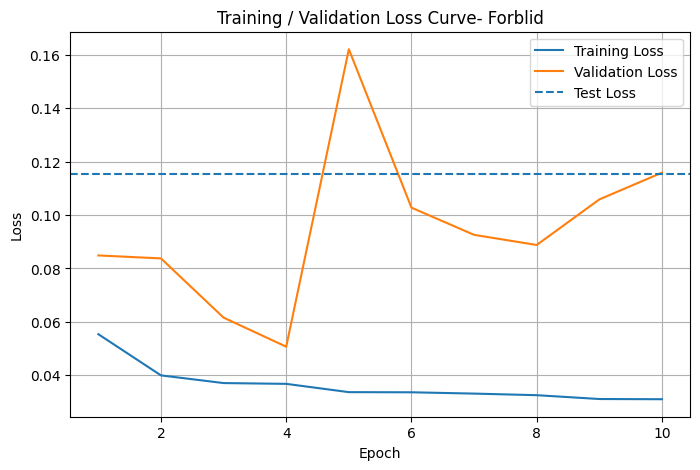

In [18]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))

# Training and validation curves
plt.plot(epochs, train_losses, label='Training Loss')
plt.plot(epochs, val_losses, label='Validation Loss')

# Optional: show test loss as a horizontal line
plt.axhline(y=avg_test_loss, linestyle='--', label='Test Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training / Validation Loss Curve- Forblid')
plt.legend()
plt.grid(True)

plt.show()

In [19]:
model_forblid_cpu = model_forblid.to("cpu")
model_forblid_cpu.eval()
scripted_model_forblid = torch.jit.script(model_forblid_cpu)
scripted_model_forblid.save("TrainedModels/lambda_forblid_test1.pt")

In [16]:
# parameters
EPOCHS = 50
BSize = 16
model_lr=3e-5

# merging all three datasets: 
dataset_all = ConcatDataset([
    dataset_SheppLogan,
    dataset_Cameraman,
    dataset_Forblid
])

# split dataset into training/validation/testing
generator = torch.Generator().manual_seed(42)

dataset_size = len(dataset_all)

train_size = int(0.70 * dataset_size)
val_size   = int(0.15 * dataset_size)
test_size  = dataset_size - train_size - val_size

train_dataset_all, val_dataset_all, test_dataset_all = random_split(
    dataset_all,
    [train_size, val_size, test_size],
    generator=generator
)

print(len(train_dataset_all))
print(len(val_dataset_all))
print(len(test_dataset_all))

loader_train_all = DataLoader(
    train_dataset_all,
    batch_size=BSize,
    shuffle=True
)

loader_val_all = DataLoader(
    val_dataset_all,
    batch_size=BSize,
    shuffle=False
)

loader_test_all = DataLoader(
    test_dataset_all,
    batch_size=BSize,
    shuffle=False
)

12098
2592
2594


In [17]:


train_losses = []
val_losses = []

model_merged = LambdaPrediction().to(device)

optimizer = torch.optim.Adam(
    model_merged.parameters(),
    lr=model_lr
)

for epoch in range(EPOCHS):

    ########################################
    # TRAIN
    ########################################
    model_merged.train()

    running_train_loss = 0.0

    pbar = tqdm(loader_train_all, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for x_curr, x_next, lam_true in pbar:

        x_curr = x_curr.to(device)
        x_next = x_next.to(device)
        lam_true = lam_true.to(device)

        # forward
        loss_i, lam_pred = model_merged(
            x_curr,
            x_next,
            lam_true
        )

        # backward
        optimizer.zero_grad()

        loss_i.backward()

        torch.nn.utils.clip_grad_norm_(
            model_merged.parameters(),
            1.0
        )

        optimizer.step()

        running_train_loss += loss_i.item()

        pbar.set_postfix(loss=loss_i.item())

    avg_train_loss = running_train_loss / len(loader_train_all)

    ########################################
    # VALIDATION
    ########################################
    model_merged.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for x_curr, x_next, lam_true in loader_val_all:

            x_curr = x_curr.to(device)
            x_next = x_next.to(device)
            lam_true = lam_true.to(device)

            loss_i, lam_pred = model_merged(
                x_curr,
                x_next,
                lam_true
            )

            running_val_loss += loss_i.item()

    avg_val_loss = running_val_loss / len(loader_val_all)

    ########################################
    # STORE HISTORY
    ########################################
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {avg_train_loss:.6f} | "
        f"Val Loss: {avg_val_loss:.6f}"
    )

Epoch 1/50: 100%|████████████████| 757/757 [03:16<00:00,  3.86it/s, loss=0.0287]


Epoch 1/50 | Train Loss: 0.057502 | Val Loss: 0.065760


Epoch 2/50: 100%|████████████████| 757/757 [03:11<00:00,  3.96it/s, loss=0.0321]


Epoch 2/50 | Train Loss: 0.050016 | Val Loss: 0.045421


Epoch 3/50: 100%|█████████████████| 757/757 [03:10<00:00,  3.97it/s, loss=0.215]


...

Epoch 48/50 | Train Loss: 0.034402 | Val Loss: 0.090906


Epoch 49/50: 100%|████████████████| 757/757 [03:04<00:00,  4.11it/s, loss=0.143]


Epoch 49/50 | Train Loss: 0.034088 | Val Loss: 0.054269


Epoch 50/50: 100%|███████████████| 757/757 [03:06<00:00,  4.07it/s, loss=0.0651]


Epoch 50/50 | Train Loss: 0.034040 | Val Loss: 0.072273


In [18]:
# testing
model_merged.eval()

test_loss = 0.0

with torch.no_grad():
    for x_curr, x_next, lam_true in loader_test_all:

        x_curr = x_curr.to(device)
        x_next = x_next.to(device)
        lam_true = lam_true.to(device)

        loss_i, lam_pred = model_merged(
            x_curr,
            x_next,
            lam_true
        )
            
        test_loss += loss_i.item()

avg_test_loss = test_loss / len(loader_test_all)

print("Test Loss:", avg_test_loss)

Test Loss: 0.06901827709395096


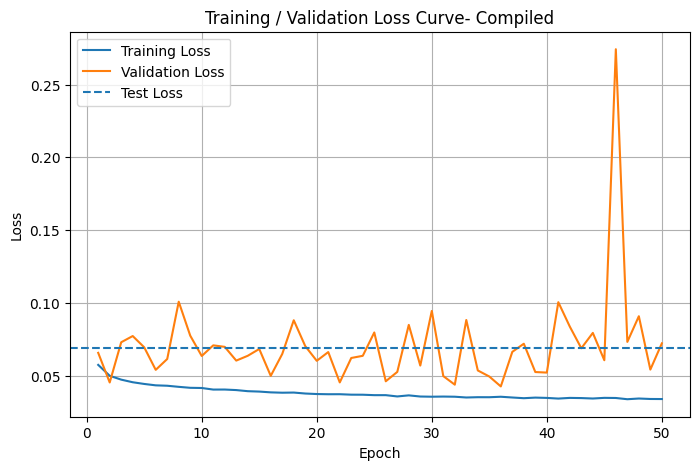

In [19]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))

# Training and validation curves
plt.plot(epochs, train_losses, label='Training Loss')
plt.plot(epochs, val_losses, label='Validation Loss')

# Optional: show test loss as a horizontal line
plt.axhline(y=avg_test_loss, linestyle='--', label='Test Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training / Validation Loss Curve- Compiled')
plt.legend()
plt.grid(True)

plt.show()

In [20]:
model_merged_cpu = model_merged.to("cpu")
model_merged_cpu.eval()
scripted_model_merged = torch.jit.script(model_merged_cpu)
scripted_model_merged.save("TrainedModels/lambda_merged_test1.pt")